In [1]:
# Ejecucion local: no se monta Google Drive.
from pathlib import Path
print(f"Directorio de trabajo: {Path.cwd()}")


Directorio de trabajo: e:\EAN\TESIS_MAESTRIA\Ciencia_de_datos\experimentos


In [2]:
# ============================================================
# 1. IMPORTAR LIBRERÍAS NECESARIAS
# ============================================================

import pandas as pd
import numpy as np

# ============================================================
# 2. CARGAR DATASET DESDE ARCHIVO XLSX
# ============================================================
# En Google Colab puedes subir el archivo manualmente o montarlo desde Drive.
# Aquí asumimos que el archivo está en la ruta actual de trabajo.

ruta_archivo = "df_consumo_bime_clima_v3.xlsx"   # <-- Cambia este nombre por el tuyo

# Leer archivo Excel
df = pd.read_excel(ruta_archivo)

# Mostrar primeras filas para verificar carga correcta
print("Dataset cargado correctamente.")
display(df.head())

# Mostrar dimensiones iniciales
print(f"\nDimensiones iniciales del dataset: {df.shape}")

# ============================================================
# 3. DEFINIR VARIABLE OBJETIVO (TARGET)
# ============================================================

target = "consumo_promedio"

# Verificar que exista en el dataset
if target not in df.columns:
    raise ValueError(f"La variable objetivo '{target}' no existe en el dataset.")

# ============================================================
# 4. VARIABLES A ELIMINAR SEGÚN ANÁLISIS DE INGENIERÍA
# ============================================================

columnas_eliminar = [

    # --------------------------------------------------------
    # Variables con posible DATA LEAKAGE
    # (Muy relacionadas o derivadas directamente del target)
    # --------------------------------------------------------
    "metros_cubicos",
    "facturas",
    "suscriptores_facturados",
    "suscriptores_con_medidor",

    # --------------------------------------------------------
    # Variables categóricas / geográficas inicialmente removidas
    # --------------------------------------------------------
    "localidad",
    "latitud",
    "longitud",

    # --------------------------------------------------------
    # Variables climáticas redundantes / derivadas
    # --------------------------------------------------------
    "T2MWET",
    "T2MDEW",
    "T2M_RANGE",

    # --------------------------------------------------------
    # Variables de viento redundantes
    # --------------------------------------------------------
    "WS10M_MAX",
    "WS10M_MIN",
    "WS10M_RANGE",
    "WS2M_MAX",
    "WS2M_MIN",
    "WS2M_RANGE",

    # --------------------------------------------------------
    # Variables angulares inicialmente removidas
    # (Dirección del viento requiere transformación trigonométrica)
    # --------------------------------------------------------
    "WD10M",
    "WD2M",

    # --------------------------------------------------------
    # Variables radiativas redundantes
    # --------------------------------------------------------
    "ALLSKY_SFC_PAR_TOT",
    "CLRSKY_SFC_PAR_TOT",
    "ALLSKY_SFC_SW_DIFF",
    "ALLSKY_SFC_SW_DNI",
    "ALLSKY_SFC_UVA",
    "ALLSKY_SFC_UVB",
    "ALLSKY_SFC_UV_INDEX",
    "CLRSKY_SFC_SW_DWN",
    "TOA_SW_DWN"
]

# ============================================================
# 5. ELIMINAR SOLO COLUMNAS EXISTENTES (ROBUSTEZ)
# ============================================================
# Esto evita errores si alguna columna no está en el archivo.

columnas_existentes_eliminar = [
    col for col in columnas_eliminar if col in df.columns
]

df = df.drop(columns=columnas_existentes_eliminar)

# Mostrar columnas eliminadas
print("\nColumnas eliminadas:")
for col in columnas_existentes_eliminar:
    print(f" - {col}")

# ============================================================
# 6. SEPARAR FEATURES (X) Y TARGET (y)
# ============================================================

X = df.drop(columns=[target])
y = df[target]

# ============================================================
# 7. MOSTRAR RESUMEN FINAL
# ============================================================

print("\n==============================")
print("PREPROCESAMIENTO COMPLETADO")
print("==============================")

print(f"\nNúmero final de features: {X.shape[1]}")
print(f"Número de muestras: {X.shape[0]}")

print("\nFeatures finales utilizadas:")
for col in X.columns:
    print(f" - {col}")

# ============================================================
# 8. VISTA PRELIMINAR DEL DATASET LIMPIO
# ============================================================

display(X.head())

print("\nTarget preview:")
display(y.head())

Dataset cargado correctamente.


,año,localidad,BIMESTRE,metros_cubicos,facturas,consumo_promedio,suscriptores_facturados,suscriptores_con_medidor,latitud,longitud,...,WD10M,WD2M,WS10M,WS10M_MAX,WS10M_MIN,WS10M_RANGE,WS2M,WS2M_MAX,WS2M_MIN,WS2M_RANGE
0,2020,USAQUEN,1,4653292,213354,10.905097,212731.0,215097,4.73197,-74.05163,...,89.65,94.8,2.310,6.405,0.140,3.07,1.395,4.175,0.065,2.085
1,2020,CHAPINERO,1,2281601,93362,12.219109,93016.0,93684,4.67040,-74.04338,...,89.65,94.8,2.310,6.405,0.140,3.07,1.395,4.175,0.065,2.085
2,2020,SANTA FE,1,843631,33789,12.483811,33524.0,34703,4.60947,-74.08135,...,78.20,78.8,2.275,6.650,0.205,2.31,1.430,4.735,0.150,1.945
3,2020,SAN CRISTOBAL,1,1771678,80676,10.980205,80311.0,81072,4.58843,-74.07080,...,78.20,78.8,2.275,6.650,0.205,2.31,1.430,4.735,0.150,1.945
4,2020,USME,1,1570282,78240,10.035033,77876.0,79159,4.53286,-74.11451,...,78.20,78.8,2.275,6.650,0.205,2.31,1.430,4.735,0.150,1.945



Dimensiones iniciales del dataset: (596, 49)

Columnas eliminadas:
 - metros_cubicos
 - facturas
 - suscriptores_facturados
 - suscriptores_con_medidor
 - localidad
 - latitud
 - longitud
 - T2MWET
 - T2MDEW
 - T2M_RANGE
 - WS10M_MAX
 - WS10M_MIN
 - WS10M_RANGE
 - WS2M_MAX
 - WS2M_MIN
 - WS2M_RANGE
 - WD10M
 - WD2M
 - ALLSKY_SFC_PAR_TOT
 - CLRSKY_SFC_PAR_TOT
 - ALLSKY_SFC_SW_DIFF
 - ALLSKY_SFC_SW_DNI
 - ALLSKY_SFC_UVA
 - ALLSKY_SFC_UVB
 - ALLSKY_SFC_UV_INDEX
 - CLRSKY_SFC_SW_DWN
 - TOA_SW_DWN

PREPROCESAMIENTO COMPLETADO

Número final de features: 21
Número de muestras: 596

Features finales utilizadas:
 - año
 - BIMESTRE
 - ALLSKY_SFC_LW_DWN
 - ALLSKY_SFC_SW_DWN
 - ALLSKY_SRF_ALB
 - CLOUD_AMT
 - GWETPROF
 - GWETROOT
 - GWETTOP
 - ONI
 - PRECTOTCORR
 - PRECTOTCORR_SUM
 - PS
 - QV2M
 - RH2M
 - T2M
 - T2M_MAX
 - T2M_MIN
 - TS
 - WS10M
 - WS2M


,año,BIMESTRE,ALLSKY_SFC_LW_DWN,ALLSKY_SFC_SW_DWN,ALLSKY_SRF_ALB,CLOUD_AMT,GWETPROF,GWETROOT,GWETTOP,ONI,...,PRECTOTCORR_SUM,PS,QV2M,RH2M,T2M,T2M_MAX,T2M_MIN,TS,WS10M,WS2M
0,2020,1,31.615,19.135,0.15,62.185,0.775,0.765,0.760,0.49,...,59.16,79.585,11.865,83.595,16.04,22.470,8.820,16.32,2.310,1.395
1,2020,1,31.615,19.135,0.15,62.185,0.775,0.765,0.760,0.49,...,59.16,79.585,11.865,83.595,16.04,22.470,8.820,16.32,2.310,1.395
2,2020,1,31.615,19.135,0.15,62.185,0.705,0.640,0.655,0.49,...,77.95,82.335,12.860,78.225,19.06,27.045,9.945,19.24,2.275,1.430
3,2020,1,31.615,19.135,0.15,62.185,0.705,0.640,0.655,0.49,...,77.95,82.335,12.860,78.225,19.06,27.045,9.945,19.24,2.275,1.430
4,2020,1,31.615,19.135,0.15,62.185,0.705,0.640,0.655,0.49,...,77.95,82.335,12.860,78.225,19.06,27.045,9.945,19.24,2.275,1.430



Target preview:


0    10.905097
1    12.219109
2    12.483811
3    10.980205
4    10.035033
Name: consumo_promedio, dtype: float64

In [3]:
# ============================================================
# 9. IMPORTAR LIBRERÍAS PARA PREPROCESAMIENTO Y PYTORCH
# ============================================================

import math
import torch
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ============================================================
# 10. HACER UNA COPIA DE SEGURIDAD DE X Y y
# ============================================================
# Esto evita modificar accidentalmente los datos originales.

X_model = X.copy()
y_model = y.copy()

# ============================================================
# 11. TRANSFORMAR BIMESTRE A REPRESENTACIÓN CÍCLICA
# ============================================================
# BIMESTRE toma valores periódicos: 1, 2, 3, 4, 5, 6
# El problema de dejarlo como entero es que:
# - 1 y 6 parecen lejanos numéricamente
# - pero realmente son cercanos en el ciclo anual
#
# Por eso usamos:
#   sin(2*pi*bimestre/6)
#   cos(2*pi*bimestre/6)

if "BIMESTRE" in X_model.columns:
    # Convertir BIMESTRE a numérico por seguridad
    X_model["BIMESTRE"] = pd.to_numeric(X_model["BIMESTRE"], errors="coerce")

    # Crear representación cíclica
    X_model["BIMESTRE_sin"] = np.sin(2 * np.pi * X_model["BIMESTRE"] / 6)
    X_model["BIMESTRE_cos"] = np.cos(2 * np.pi * X_model["BIMESTRE"] / 6)

    # Eliminar la columna original porque ya quedó representada mejor
    X_model = X_model.drop(columns=["BIMESTRE"])

    print("Se transformó 'BIMESTRE' a variables cíclicas: BIMESTRE_sin y BIMESTRE_cos")
else:
    print("La columna 'BIMESTRE' no está presente en X_model")

# ============================================================
# 12. ASEGURAR QUE 'año' SEA NUMÉRICO
# ============================================================
# En muchos archivos Excel algunas columnas llegan como texto.
# Aquí obligamos a que 'año' sea numérico si existe.

if "año" in X_model.columns:
    X_model["año"] = pd.to_numeric(X_model["año"], errors="coerce")
    print("La columna 'año' fue convertida a formato numérico.")
else:
    print("La columna 'año' no está presente en X_model")

# ============================================================
# 13. ASEGURAR QUE TODAS LAS FEATURES SEAN NUMÉRICAS
# ============================================================
# Como vas a entrenar una red neuronal tabular en PyTorch,
# todas las entradas deben ser numéricas.

for col in X_model.columns:
    X_model[col] = pd.to_numeric(X_model[col], errors="coerce")

# También forzamos el target a numérico
y_model = pd.to_numeric(y_model, errors="coerce")

# ============================================================
# 13.1 TRANSFORMAR EL TARGET CON log1p
# ============================================================
# Dado que consumo_promedio tiene una distribución muy sesgada
# y presenta valores extremos muy grandes, usamos log1p:
#
#   log1p(y) = log(1 + y)
#
# Esto comprime la cola larga del target y ayuda a que el modelo
# aprenda mejor la estructura general del problema.
#
# IMPORTANTE:
# Esto solo funciona si y >= 0, lo cual en este problema tiene sentido.
# Si hubiera valores negativos, habría que revisar antes.

if (y_model < 0).any():
    raise ValueError("La transformación log1p no puede aplicarse porque existen valores negativos en el target.")

y_model = np.log1p(y_model)

print("Se aplicó transformación log1p al target 'consumo_promedio'.")

# ============================================================
# 14. ELIMINAR FILAS DONDE EL TARGET SEA NULO
# ============================================================
# No se puede entrenar si la variable objetivo está vacía.

mask_target_valido = y_model.notna()

X_model = X_model.loc[mask_target_valido].reset_index(drop=True)
y_model = y_model.loc[mask_target_valido].reset_index(drop=True)

print(f"\nDespués de quitar targets nulos:")
print(f"X_model: {X_model.shape}")
print(f"y_model: {y_model.shape}")

# ============================================================
# 15. DIVIDIR EN TRAIN, VALIDATION Y TEST
# ============================================================
# Buena práctica:
# - train: para entrenar
# - validation: para ajustar hiperparámetros / early stopping
# - test: para evaluar el resultado final
#
# Aquí usamos:
# - 70% train
# - 15% validation
# - 15% test

X_train, X_temp, y_train, y_temp = train_test_split(
    X_model,
    y_model,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("\nDivisión de datos:")
print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Val:   {X_val.shape}, {y_val.shape}")
print(f"Test:  {X_test.shape}, {y_test.shape}")

# ============================================================
# 16. IMPUTAR VALORES FALTANTES EN FEATURES
# ============================================================
# Muy importante:
# El imputador debe ajustarse SOLO con train
# y luego aplicarse a val/test.
#
# Aquí usamos la mediana porque suele ser robusta
# ante valores extremos en variables climáticas.

imputer_X = SimpleImputer(strategy="median")

X_train_imputed = imputer_X.fit_transform(X_train)
X_val_imputed   = imputer_X.transform(X_val)
X_test_imputed  = imputer_X.transform(X_test)

# ============================================================
# 17. ESCALAR FEATURES
# ============================================================
# Las redes neuronales suelen entrenar mejor cuando las variables
# tienen escalas comparables.
#
# Ajustamos el scaler SOLO con train y aplicamos a val/test.

scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train_imputed)
X_val_scaled   = scaler_X.transform(X_val_imputed)
X_test_scaled  = scaler_X.transform(X_test_imputed)

# ============================================================
# 18. ESCALAR EL TARGET (OPCIONAL PERO RECOMENDADO)
# ============================================================
# En regresión con deep learning, muchas veces ayuda escalar la salida.
# Esto estabiliza el entrenamiento si el target tiene magnitud grande.
#
# Luego, al evaluar, puedes revertir la escala.

scaler_y = StandardScaler()

y_train_reshaped = y_train.values.reshape(-1, 1)
y_val_reshaped   = y_val.values.reshape(-1, 1)
y_test_reshaped  = y_test.values.reshape(-1, 1)

y_train_scaled = scaler_y.fit_transform(y_train_reshaped)
y_val_scaled   = scaler_y.transform(y_val_reshaped)
y_test_scaled  = scaler_y.transform(y_test_reshaped)

# ============================================================
# 19. CONVERTIR A TENSORES DE PYTORCH
# ============================================================
# PyTorch trabaja con tensores. Para regresión usamos float32.

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
y_val_tensor   = torch.tensor(y_val_scaled, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test_scaled, dtype=torch.float32)

# ============================================================
# 20. CREAR TensorDataset
# ============================================================
# Esto empaqueta features y target juntos.

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

# ============================================================
# 21. CREAR DataLoaders
# ============================================================
# batch_size = cuántas muestras ve el modelo por iteración
# shuffle=True solo en train para mezclar ejemplos

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ============================================================
# 22. MOSTRAR RESUMEN FINAL DEL PREPROCESAMIENTO
# ============================================================

print("\n==============================")
print("PREPROCESAMIENTO PARA PYTORCH COMPLETADO")
print("==============================")

print(f"\nNúmero final de features usadas por el modelo: {X_train_tensor.shape[1]}")
print(f"Batch size: {batch_size}")

print("\nNombres finales de las features:")
columnas_finales = X_model.columns.tolist()
for i, col in enumerate(columnas_finales, start=1):
    print(f"{i}. {col}")

print("\nTamaños de tensores:")
print(f"X_train_tensor: {X_train_tensor.shape}")
print(f"y_train_tensor: {y_train_tensor.shape}")
print(f"X_val_tensor:   {X_val_tensor.shape}")
print(f"y_val_tensor:   {y_val_tensor.shape}")
print(f"X_test_tensor:  {X_test_tensor.shape}")
print(f"y_test_tensor:  {y_test_tensor.shape}")

Se transformó 'BIMESTRE' a variables cíclicas: BIMESTRE_sin y BIMESTRE_cos
La columna 'año' fue convertida a formato numérico.
Se aplicó transformación log1p al target 'consumo_promedio'.

Después de quitar targets nulos:
X_model: (596, 22)
y_model: (596,)

División de datos:
Train: (417, 22), (417,)
Val:   (89, 22), (89,)
Test:  (90, 22), (90,)

PREPROCESAMIENTO PARA PYTORCH COMPLETADO

Número final de features usadas por el modelo: 22
Batch size: 32

Nombres finales de las features:
1. año
2. ALLSKY_SFC_LW_DWN
3. ALLSKY_SFC_SW_DWN
4. ALLSKY_SRF_ALB
5. CLOUD_AMT
6. GWETPROF
7. GWETROOT
8. GWETTOP
9. ONI
10. PRECTOTCORR
11. PRECTOTCORR_SUM
12. PS
13. QV2M
14. RH2M
15. T2M
16. T2M_MAX
17. T2M_MIN
18. TS
19. WS10M
20. WS2M
21. BIMESTRE_sin
22. BIMESTRE_cos

Tamaños de tensores:
X_train_tensor: torch.Size([417, 22])
y_train_tensor: torch.Size([417, 1])
X_val_tensor:   torch.Size([89, 22])
y_val_tensor:   torch.Size([89, 1])
X_test_tensor:  torch.Size([90, 22])
y_test_tensor:  torch.Size([

Dispositivo en uso: cpu
TabularRegressor(
  (network): Sequential(
    (0): Linear(in_features=22, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)
Época 001/200 | Train Loss: 0.364390 | Val Loss: 0.554993
Época 002/200 | Train Loss: 0.354061 | Val Loss: 0.551714
Época 003/200 | Train Loss: 0.348939 | Val Loss: 0.549958
Época 004/200 | Train Loss: 0.345294 | Val Loss: 0.549344
Época 005/200 | Train Loss: 0.342651 | Val Loss: 0.549458
Época 006/200 | Train Loss: 0.340422 | Val Loss: 0.549455
Época 007/200 | Train Loss: 0.337670 | Val Loss: 0.549610
Época 008/200 | Train Loss: 0.334594 | Val Loss: 0.550120
Época 009/200 | Train Loss: 0.332220 | Val Loss: 0.551865
Época 010/200 | Train Loss: 0.329986 | Val Loss: 0.552593
Época 011/200 | Train Loss: 0.326879 | Val Loss: 0.553036
Ép

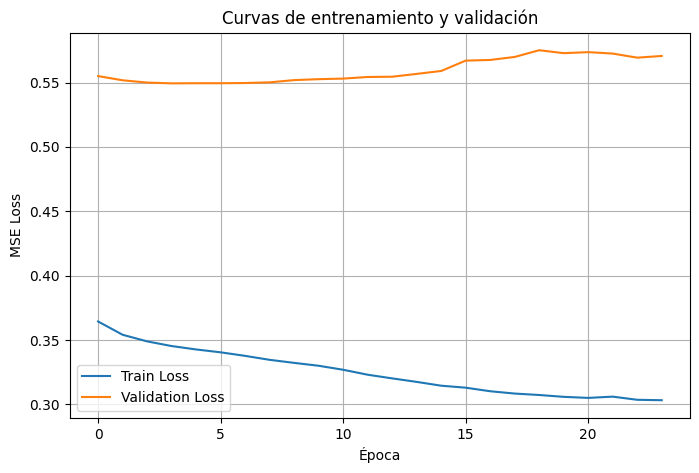


RESULTADOS FINALES EN TEST
MAE  : 1.5582
RMSE : 2.3076
R²   : -0.0475

Primeras 10 predicciones:


,Valor_real,Prediccion,Error_absoluto
0,11.404461,11.103496,0.300965
1,11.192152,11.197231,0.005079
2,10.600931,11.088551,0.487619
3,15.794586,10.992516,4.802071
4,11.060143,11.301677,0.241533
5,16.104216,11.078931,5.025285
6,10.845301,11.103496,0.258195
7,14.570528,11.122272,3.448256
8,10.067234,10.888960,0.821726
9,12.082005,10.992885,1.089120


In [5]:
# ============================================================
# 23. IMPORTAR LIBRERÍAS PARA EL MODELO Y EVALUACIÓN
# ============================================================

import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ============================================================
# 24. DEFINIR DISPOSITIVO DE CÓMPUTO
# ============================================================
# Si Colab tiene GPU disponible, el modelo la usará.
# Si no, entrenará en CPU.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo en uso: {device}")

# ============================================================
# 25. DEFINIR ARQUITECTURA DEL MODELO
# ============================================================
# Esta es una red neuronal densa (MLP) apropiada para datos tabulares.
#
# Estructura:
# entrada -> capa oculta -> ReLU -> dropout
#         -> capa oculta -> ReLU -> dropout
#         -> capa oculta -> ReLU
#         -> salida (1 neurona para regresión)

class TabularRegressor(nn.Module):
    def __init__(self, input_dim):
        super(TabularRegressor, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

# Crear instancia del modelo
input_dim = X_train_tensor.shape[1]
model = TabularRegressor(input_dim=input_dim).to(device)

print(model)

# ============================================================
# 26. FUNCIÓN DE PÉRDIDA ROBUSTA
# ============================================================
# HuberLoss es más robusta frente a outliers que MSELoss.
# Combina comportamiento cuadrático para errores pequeños
# y lineal para errores grandes.

optimizer = optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.HuberLoss(delta=1.0)

# ============================================================
# 27. FUNCIÓN DE ENTRENAMIENTO DE UNA ÉPOCA
# ============================================================

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()  # modo entrenamiento

    running_loss = 0.0

    for X_batch, y_batch in dataloader:
        # Mover batch a CPU/GPU
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Limpiar gradientes acumulados
        optimizer.zero_grad()

        # Forward pass
        outputs = model(X_batch)

        # Calcular pérdida
        loss = criterion(outputs, y_batch)

        # Backpropagation
        loss.backward()

        # Actualizar pesos
        optimizer.step()

        # Acumular pérdida ponderada por tamaño de batch
        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss

# ============================================================
# 28. FUNCIÓN DE VALIDACIÓN
# ============================================================

def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()  # modo evaluación

    running_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss

# ============================================================
# 29. ENTRENAMIENTO COMPLETO CON EARLY STOPPING
# ============================================================

num_epochs = 200
patience = 20  # número de épocas sin mejora permitidas

train_losses = []
val_losses = []

best_val_loss = float("inf")
epochs_without_improvement = 0

best_model_path = "best_tabular_regressor_log_huber.pth"

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Época {epoch+1:03d}/{num_epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    # Guardar mejor modelo
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        epochs_without_improvement += 1

    # Early stopping
    if epochs_without_improvement >= patience:
        print("\nSe activó early stopping.")
        break

# ============================================================
# 30. CARGAR EL MEJOR MODELO GUARDADO
# ============================================================

model.load_state_dict(torch.load(best_model_path))
model.eval()

print(f"\nMejor modelo cargado desde: {best_model_path}")
print(f"Mejor pérdida de validación: {best_val_loss:.6f}")

# ============================================================
# 31. GRAFICAR CURVAS DE PÉRDIDA
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Época")
plt.ylabel("MSE Loss")
plt.title("Curvas de entrenamiento y validación")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 32. FUNCIÓN PARA OBTENER PREDICCIONES
# ============================================================

def predict(model, dataloader, device):
    model.eval()

    preds = []
    targets = []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)

            outputs = model(X_batch)

            preds.append(outputs.cpu().numpy())
            targets.append(y_batch.numpy())

    preds = np.vstack(preds)
    targets = np.vstack(targets)

    return preds, targets

# ============================================================
# 33. PREDECIR SOBRE EL CONJUNTO DE TEST
# ============================================================

y_pred_scaled, y_true_scaled = predict(model, test_loader, device)

# ============================================================
# 34. DEVOLVER LAS PREDICCIONES A LA ESCALA ORIGINAL
# ============================================================
# Como el target fue transformado con log1p y además escalado,
# debemos revertir ambas transformaciones en el orden correcto:
#
# 1) inverse_transform del scaler_y
# 2) expm1 para volver de log1p a escala original

y_pred_log = scaler_y.inverse_transform(y_pred_scaled)
y_true_log = scaler_y.inverse_transform(y_true_scaled)

# Volver a la escala original del consumo
y_pred_real = np.expm1(y_pred_log)
y_true_real = np.expm1(y_true_log)

# ============================================================
# 35. CALCULAR MÉTRICAS FINALES EN ESCALA REAL
# ============================================================

mae = mean_absolute_error(y_true_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))
r2 = r2_score(y_true_real, y_pred_real)

print("\n==============================")
print("RESULTADOS FINALES EN TEST")
print("==============================")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

# ============================================================
# 36. MOSTRAR ALGUNAS PREDICCIONES VS VALORES REALES
# ============================================================

resultados = pd.DataFrame({
    "Valor_real": y_true_real.flatten(),
    "Prediccion": y_pred_real.flatten(),
    "Error_absoluto": np.abs(y_true_real.flatten() - y_pred_real.flatten())
})

print("\nPrimeras 10 predicciones:")
display(resultados.head(10))

BASELINE: DummyRegressor (predice la media)
MAE  baseline: 0.1225
RMSE baseline: 0.1606
R²   baseline: -0.0061

RESUMEN DESCRIPTIVO DEL TARGET (consumo_promedio)
count    596.000000
mean       2.521671
std        0.190805
min        1.805111
25%        2.408353
50%        2.472658
75%        2.547733
max        3.674064
Name: consumo_promedio, dtype: float64


e:\EAN\TESIS_MAESTRIA\Ciencia_de_datos\experimentos\hidrico_exp\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


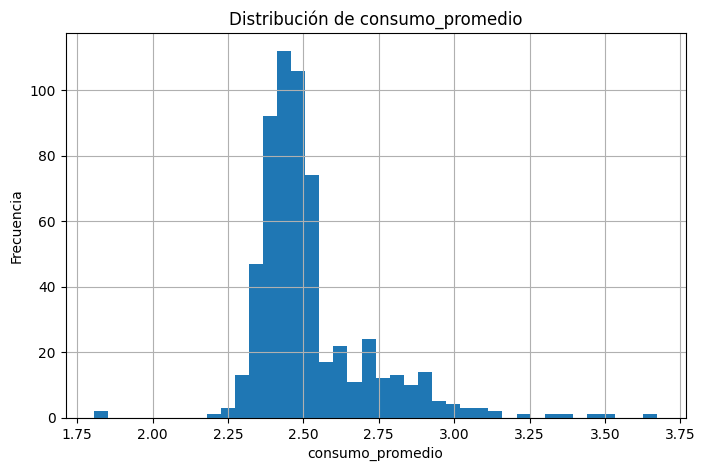

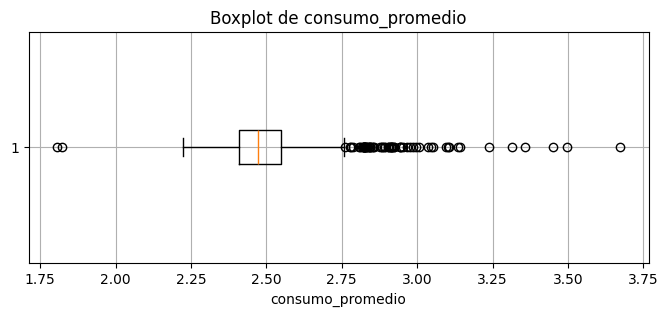


ANÁLISIS DE OUTLIERS DEL TARGET
Q1: 2.4084
Q3: 2.5477
IQR: 0.1394
Límite inferior: 2.1993
Límite superior: 2.7568
Número de outliers detectados: 66
Porcentaje de outliers: 11.07%

PRIMERAS FILAS DE RESULTADOS EN TEST


,y_real,y_pred,residuo,error_absoluto,error_porcentual_abs
0,11.404461,11.103496,0.300965,0.300965,2.639014
1,11.192152,11.197231,-0.005079,0.005079,0.045382
2,10.600931,11.088551,-0.487619,0.487619,4.599779
3,15.794586,10.992516,4.802071,4.802071,30.403269
4,11.060143,11.301677,-0.241533,0.241533,2.183817
5,16.104216,11.078931,5.025285,5.025285,31.204779
6,10.845301,11.103496,-0.258195,0.258195,2.380708
7,14.570528,11.122272,3.448256,3.448256,23.665962
8,10.067234,10.888960,-0.821726,0.821726,8.162379
9,12.082005,10.992885,1.089120,1.089120,9.014398



20 PEORES PREDICCIONES EN TEST


,y_real,y_pred,residuo,error_absoluto,error_porcentual_abs
84,21.093748,11.194123,9.899625,9.899625,46.931557
33,17.420832,11.127716,6.293116,6.293116,36.124084
43,17.041599,11.139143,5.902456,5.902456,34.635574
88,17.271118,11.377663,5.893456,5.893456,34.123188
89,16.849001,11.068139,5.780862,5.780862,34.309818
5,16.104216,11.078931,5.025285,5.025285,31.204779
3,15.794586,10.992516,4.802071,4.802071,30.403269
37,15.583334,11.213627,4.369707,4.369707,28.040899
42,14.732734,11.244089,3.488645,3.488645,23.679548
7,14.570528,11.122272,3.448256,3.448256,23.665962


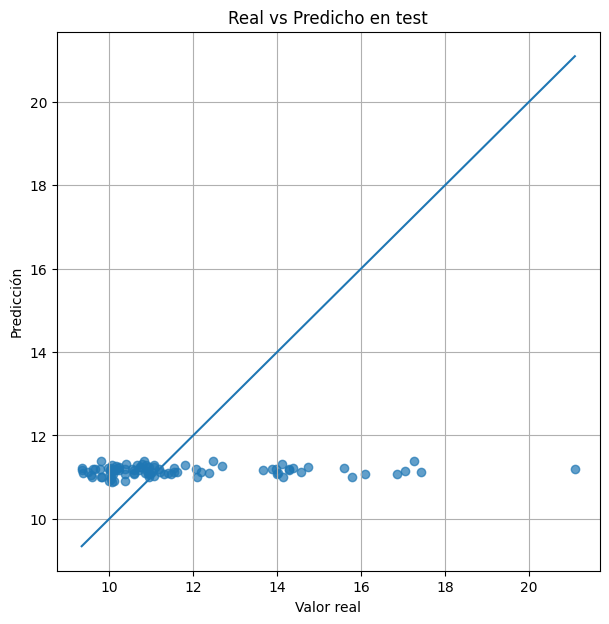

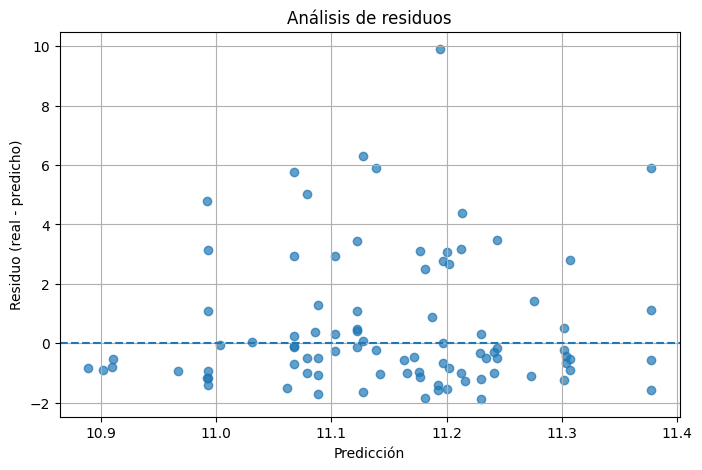

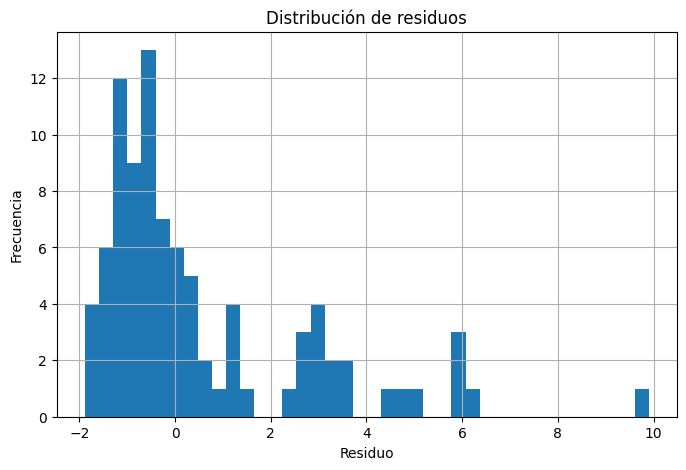


TOP 20 FEATURES MÁS CORRELACIONADAS CON EL TARGET


,correlacion
BIMESTRE_sin,0.135817
PS,-0.107194
año,-0.070959
PRECTOTCORR,0.049326
PRECTOTCORR_SUM,0.046646
CLOUD_AMT,-0.046277
T2M_MAX,-0.038600
T2M,-0.035340
T2M_MIN,-0.034606
TS,-0.031123


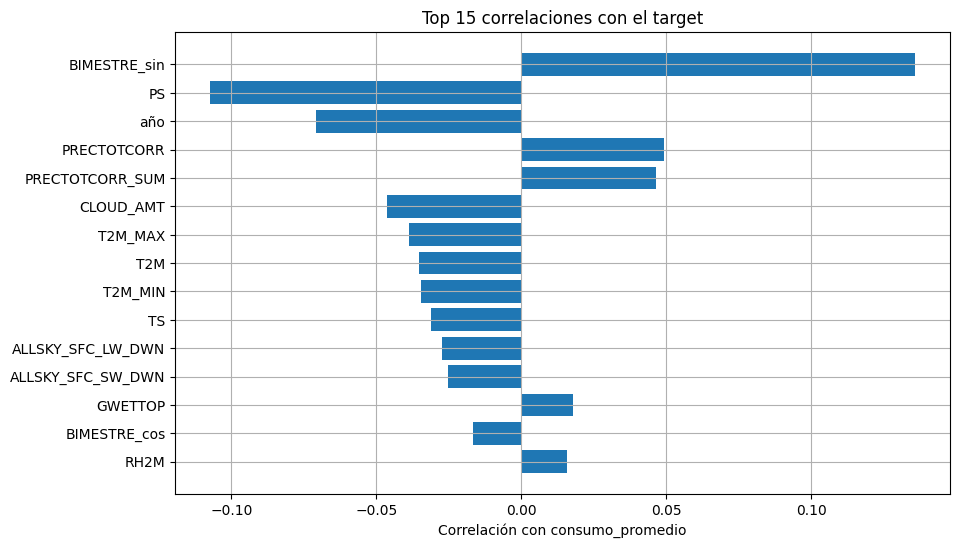


IMPORTANCIA POR PERMUTACIÓN


,feature,importance_mean,importance_std
20,BIMESTRE_sin,0.000136,0.000084
13,RH2M,0.000060,0.000039
5,GWETPROF,0.000048,0.000033
6,GWETROOT,0.000034,0.000036
4,CLOUD_AMT,0.000032,0.000055
2,ALLSKY_SFC_SW_DWN,0.000008,0.000068
11,PS,0.000003,0.000054
12,QV2M,-0.000009,0.000069
0,año,-0.000010,0.000053
14,T2M,-0.000025,0.000048


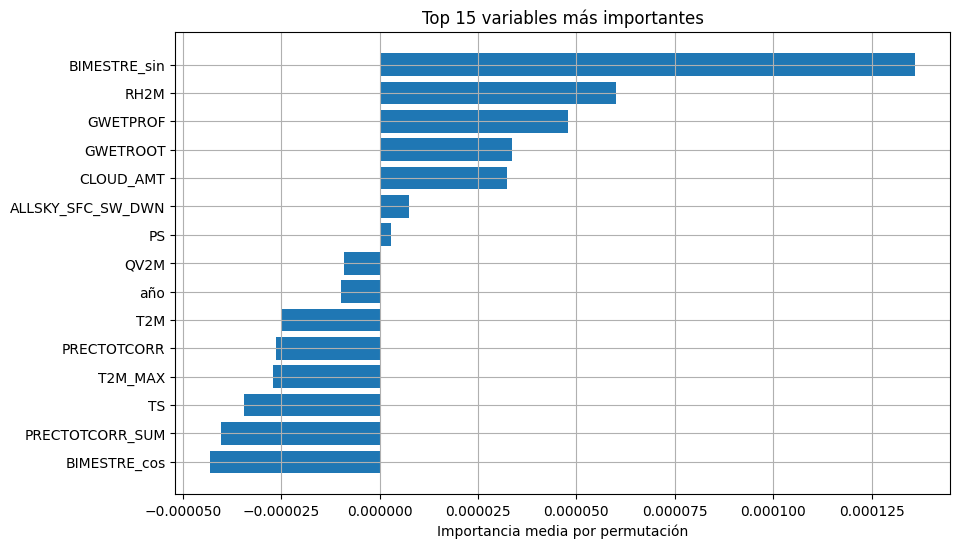

Forma original de SHAP: (90, 22, 1)
Forma ajustada de SHAP: (90, 22)

GENERANDO SHAP SUMMARY PLOT...


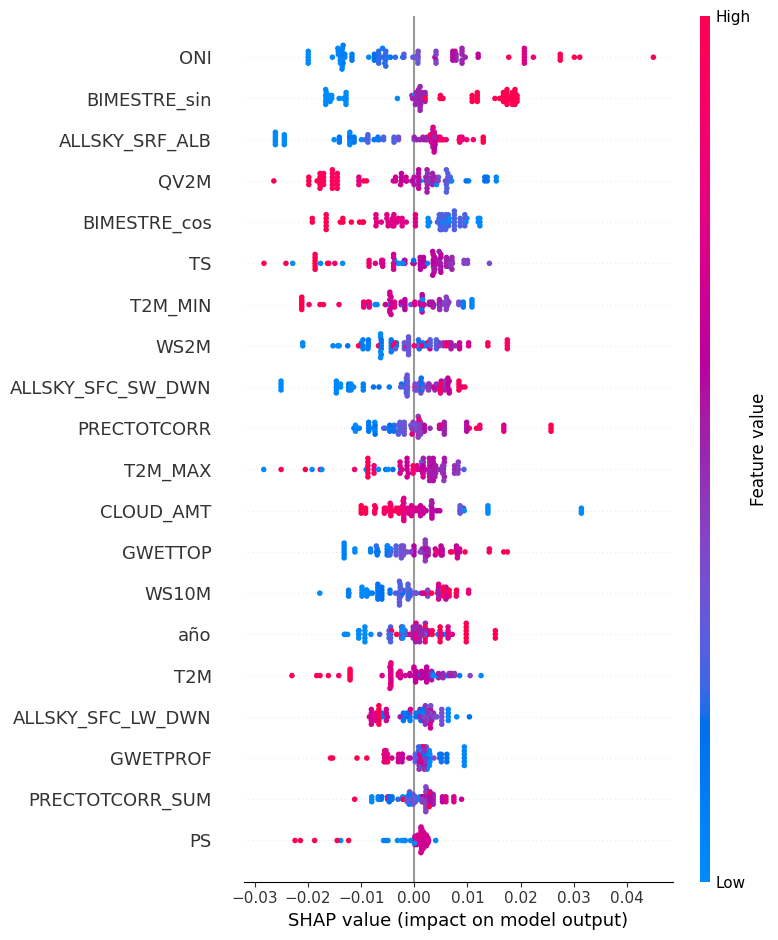


IMPORTANCIA GLOBAL SEGÚN SHAP


,feature,mean_abs_shap
8,ONI,0.011359
20,BIMESTRE_sin,0.010394
3,ALLSKY_SRF_ALB,0.008809
12,QV2M,0.008286
21,BIMESTRE_cos,0.007171
17,TS,0.006875
16,T2M_MIN,0.006533
19,WS2M,0.006289
2,ALLSKY_SFC_SW_DWN,0.006221
9,PRECTOTCORR,0.005477


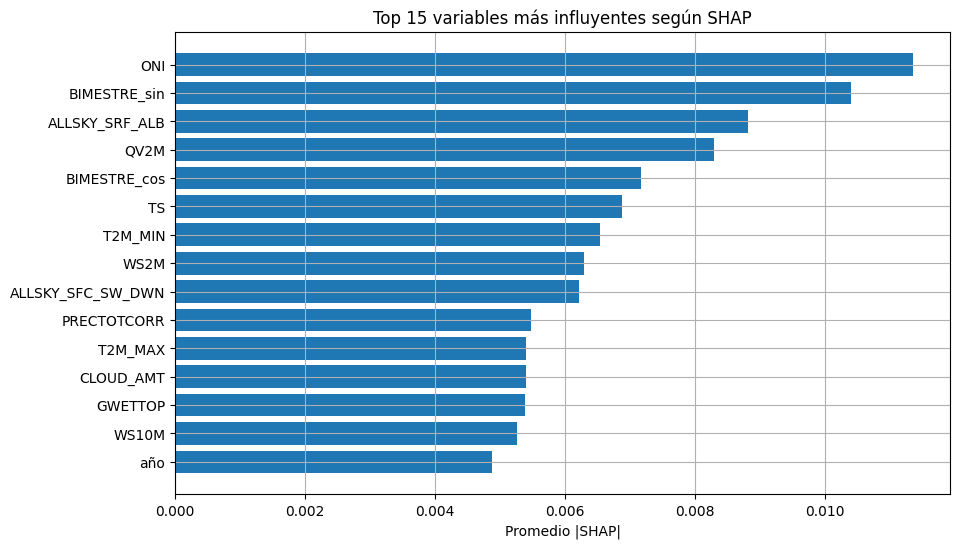

In [6]:
# ============================================================
# 37. IMPORTAR LIBRERÍAS ADICIONALES PARA DIAGNÓSTICO
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# Intentaremos usar SHAP. Si no está instalado en Colab, lo instalamos.
try:
    import shap
except ImportError:
    !pip install shap -q
    import shap

# ============================================================
# 38. EVALUAR UN BASELINE MUY SIMPLE
# ============================================================
# Antes de confiar en un modelo profundo, siempre conviene compararlo
# contra un modelo trivial. Aquí usamos DummyRegressor con estrategia "mean",
# que predice siempre el promedio del target de entrenamiento.
#
# Si tu red neuronal no supera claramente este baseline, entonces todavía
# no está capturando una señal útil de manera robusta.

dummy_model = DummyRegressor(strategy="mean")

# El baseline de sklearn necesita datos numéricos sin NaN y preferiblemente
# ya transformados. Por eso usamos las features escaladas.
dummy_model.fit(X_train_scaled, y_train.values)

# Predecir en test con el baseline
y_dummy_pred = dummy_model.predict(X_test_scaled)

# Calcular métricas del baseline
dummy_mae = mean_absolute_error(y_test.values, y_dummy_pred)
dummy_rmse = np.sqrt(mean_squared_error(y_test.values, y_dummy_pred))
dummy_r2 = r2_score(y_test.values, y_dummy_pred)

print("=" * 60)
print("BASELINE: DummyRegressor (predice la media)")
print("=" * 60)
print(f"MAE  baseline: {dummy_mae:.4f}")
print(f"RMSE baseline: {dummy_rmse:.4f}")
print(f"R²   baseline: {dummy_r2:.4f}")

# ============================================================
# 39. RESUMEN DESCRIPTIVO DEL TARGET
# ============================================================
# Esto permite entender si consumo_promedio tiene distribución sesgada,
# colas largas o valores extremos.

print("\n" + "=" * 60)
print("RESUMEN DESCRIPTIVO DEL TARGET (consumo_promedio)")
print("=" * 60)
print(y_model.describe())

# ============================================================
# 40. GRAFICAR DISTRIBUCIÓN DEL TARGET
# ============================================================
# Hacemos dos gráficos:
# 1) histograma del target original
# 2) boxplot del target
#
# Si el target tiene una cola muy larga o muchos extremos, esto quedará visible.

plt.figure(figsize=(8, 5))
plt.hist(y_model, bins=40)
plt.xlabel("consumo_promedio")
plt.ylabel("Frecuencia")
plt.title("Distribución de consumo_promedio")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 3))
plt.boxplot(y_model, vert=False)
plt.xlabel("consumo_promedio")
plt.title("Boxplot de consumo_promedio")
plt.grid(True)
plt.show()

# ============================================================
# 41. DETECTAR OUTLIERS DEL TARGET CON IQR
# ============================================================
# Regla clásica:
# outlier si está por debajo de Q1 - 1.5*IQR
# o por encima de Q3 + 1.5*IQR

Q1 = y_model.quantile(0.25)
Q3 = y_model.quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_target = y_model[(y_model < limite_inferior) | (y_model > limite_superior)]

print("\n" + "=" * 60)
print("ANÁLISIS DE OUTLIERS DEL TARGET")
print("=" * 60)
print(f"Q1: {Q1:.4f}")
print(f"Q3: {Q3:.4f}")
print(f"IQR: {IQR:.4f}")
print(f"Límite inferior: {limite_inferior:.4f}")
print(f"Límite superior: {limite_superior:.4f}")
print(f"Número de outliers detectados: {len(outliers_target)}")
print(f"Porcentaje de outliers: {100 * len(outliers_target) / len(y_model):.2f}%")

# ============================================================
# 42. CREAR DATAFRAME DE RESULTADOS EN TEST
# ============================================================
# Aquí consolidamos valores reales, predicciones y residuos.

resultados_test = pd.DataFrame({
    "y_real": y_true_real.flatten(),
    "y_pred": y_pred_real.flatten()
})

# Error firmado: positivo si el modelo subestima, negativo si sobreestima
resultados_test["residuo"] = resultados_test["y_real"] - resultados_test["y_pred"]

# Error absoluto
resultados_test["error_absoluto"] = np.abs(resultados_test["residuo"])

# Error porcentual absoluto, con protección para división por cero
resultados_test["error_porcentual_abs"] = np.where(
    np.abs(resultados_test["y_real"]) > 1e-8,
    100 * resultados_test["error_absoluto"] / np.abs(resultados_test["y_real"]),
    np.nan
)

print("\n" + "=" * 60)
print("PRIMERAS FILAS DE RESULTADOS EN TEST")
print("=" * 60)
display(resultados_test.head(10))

# ============================================================
# 43. MOSTRAR LOS 20 PEORES CASOS
# ============================================================
# Esto es clave para entender por qué el RMSE salió tan alto.

peores_casos = resultados_test.sort_values(by="error_absoluto", ascending=False).head(20)

print("\n" + "=" * 60)
print("20 PEORES PREDICCIONES EN TEST")
print("=" * 60)
display(peores_casos)

# ============================================================
# 44. GRÁFICO REAL VS PREDICHO
# ============================================================
# Si el modelo fuera ideal, los puntos caerían cerca de la diagonal y = x.

plt.figure(figsize=(7, 7))
plt.scatter(resultados_test["y_real"], resultados_test["y_pred"], alpha=0.7)

# Dibujar diagonal ideal
min_val = min(resultados_test["y_real"].min(), resultados_test["y_pred"].min())
max_val = max(resultados_test["y_real"].max(), resultados_test["y_pred"].max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("Real vs Predicho en test")
plt.grid(True)
plt.show()

# ============================================================
# 45. GRÁFICO DE RESIDUOS
# ============================================================
# Sirve para detectar sesgos sistemáticos.
# Por ejemplo:
# - si el modelo subestima valores grandes,
# - o si sobreestima valores pequeños.

plt.figure(figsize=(8, 5))
plt.scatter(resultados_test["y_pred"], resultados_test["residuo"], alpha=0.7)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicción")
plt.ylabel("Residuo (real - predicho)")
plt.title("Análisis de residuos")
plt.grid(True)
plt.show()

# ============================================================
# 46. HISTOGRAMA DE RESIDUOS
# ============================================================
# Idealmente los residuos deberían estar centrados en cero
# y no tener colas exageradamente largas.

plt.figure(figsize=(8, 5))
plt.hist(resultados_test["residuo"], bins=40)
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.title("Distribución de residuos")
plt.grid(True)
plt.show()

# ============================================================
# 47. CORRELACIÓN DE FEATURES CON EL TARGET
# ============================================================
# Esto NO prueba causalidad, pero sirve para tener una señal inicial
# de asociación lineal entre cada feature y consumo_promedio.

# Reconstruimos un DataFrame limpio con las features ya transformadas
# y añadimos el target original.
df_corr = X_model.copy()
df_corr["consumo_promedio"] = y_model.values

# Calcular correlación de Pearson contra el target
corr_target = df_corr.corr(numeric_only=True)["consumo_promedio"].drop("consumo_promedio")

# Ordenar de mayor a menor según correlación absoluta
corr_target_abs = corr_target.abs().sort_values(ascending=False)

print("\n" + "=" * 60)
print("TOP 20 FEATURES MÁS CORRELACIONADAS CON EL TARGET")
print("=" * 60)
display(pd.DataFrame({
    "correlacion": corr_target.loc[corr_target_abs.index]
}).head(20))

# Graficar top 15
top15_corr = corr_target_abs.head(15).index
plt.figure(figsize=(10, 6))
plt.barh(top15_corr[::-1], corr_target.loc[top15_corr][::-1])
plt.xlabel("Correlación con consumo_promedio")
plt.title("Top 15 correlaciones con el target")
plt.grid(True)
plt.show()

# ============================================================
# 48. ENVOLVER EL MODELO DE PYTORCH PARA USAR permutation_importance
# ============================================================
# sklearn espera un estimador con método predict(X).
# Creamos una clase ligera para que use el modelo entrenado de PyTorch
# y devuelva predicciones en escala original.

class TorchRegressorWrapper:
    def __init__(self, model, device, scaler_y):
        self.model = model
        self.device = device
        self.scaler_y = scaler_y

    def fit(self, X, y):
        # No hace nada; el modelo ya está entrenado.
        return self

    def predict(self, X):
        # Convertir a tensor float32
        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)

        # Desactivar gradientes
        self.model.eval()
        with torch.no_grad():
            y_pred_scaled = self.model(X_tensor).cpu().numpy()

        # Regresar a escala original
        y_pred_real_local = self.scaler_y.inverse_transform(y_pred_scaled)

        return y_pred_real_local.flatten()

# Crear wrapper
wrapped_model = TorchRegressorWrapper(model=model, device=device, scaler_y=scaler_y)

# ============================================================
# 49. IMPORTANCIA POR PERMUTACIÓN
# ============================================================
# Esta técnica mide cuánto empeora el modelo cuando se rompe
# aleatoriamente una variable.
#
# Se calcula sobre test.
# Mientras más importante sea una variable, mayor caída de desempeño
# genera su permutación.

feature_names_test = X_model.columns.tolist()

perm_result = permutation_importance(
    estimator=wrapped_model,
    X=X_test_scaled,
    y=y_test.values,
    scoring="neg_mean_squared_error",
    n_repeats=10,
    random_state=42
)

# Construir DataFrame de importancias
perm_df = pd.DataFrame({
    "feature": feature_names_test,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values(by="importance_mean", ascending=False)

print("\n" + "=" * 60)
print("IMPORTANCIA POR PERMUTACIÓN")
print("=" * 60)
display(perm_df.head(20))

# Graficar top 15
top_perm = perm_df.head(15).sort_values(by="importance_mean", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_perm["feature"], top_perm["importance_mean"])
plt.xlabel("Importancia media por permutación")
plt.title("Top 15 variables más importantes")
plt.grid(True)
plt.show()

# ============================================================
# 50. SHAP: EXPLICABILIDAD DEL MODELO
# ============================================================
# Para no volverlo demasiado pesado en Colab, usamos una muestra del train
# como background y una muestra del test para explicación.

# Seleccionar tamaño de muestra para SHAP
n_background = min(100, X_train_tensor.shape[0])
n_explain = min(100, X_test_tensor.shape[0])

# Crear subconjuntos
background_data = X_train_tensor[:n_background].to(device)
explain_data = X_test_tensor[:n_explain].to(device)

# Intentar usar DeepExplainer. Si falla por compatibilidad,
# hacemos fallback a GradientExplainer.
try:
    explainer = shap.DeepExplainer(model, background_data)
    shap_values = explainer.shap_values(explain_data)
except Exception as e:
    print("\nDeepExplainer no funcionó. Se usará GradientExplainer.")
    print(f"Motivo: {e}")
    explainer = shap.GradientExplainer(model, background_data)
    shap_values = explainer.shap_values(explain_data)

# ============================================================
# 51. NORMALIZAR LA FORMA DE SHAP
# ============================================================
# SHAP puede devolver distintos formatos dependiendo del explainer
# y de la versión de las librerías. Queremos una matriz final:
#
#   (n_muestras, n_features)

if isinstance(shap_values, list):
    shap_array = np.array(shap_values[0])
else:
    shap_array = np.array(shap_values)

print("Forma original de SHAP:", shap_array.shape)

# Caso 1: (n_samples, n_features, 1)
if shap_array.ndim == 3 and shap_array.shape[-1] == 1:
    shap_array = shap_array[:, :, 0]

# Caso 2: (1, n_samples, n_features)
elif shap_array.ndim == 3 and shap_array.shape[0] == 1:
    shap_array = shap_array[0]

# Caso 3: otras formas inesperadas
elif shap_array.ndim > 2:
    shap_array = np.squeeze(shap_array)

# Si después del squeeze sigue sin quedar 2D, forzamos validación
if shap_array.ndim != 2:
    raise ValueError(f"SHAP no quedó en forma 2D. Forma actual: {shap_array.shape}")

print("Forma ajustada de SHAP:", shap_array.shape)

# Pasar datos a numpy para graficar
X_explain_np = explain_data.detach().cpu().numpy()

# Verificar consistencia con número de features
if shap_array.shape[1] != len(feature_names_test):
    raise ValueError(
        f"El número de columnas de SHAP ({shap_array.shape[1]}) "
        f"no coincide con el número de features ({len(feature_names_test)})."
    )

# ============================================================
# 52. SHAP SUMMARY PLOT
# ============================================================

print("\n" + "=" * 60)
print("GENERANDO SHAP SUMMARY PLOT...")
print("=" * 60)

shap.summary_plot(
    shap_array,
    X_explain_np,
    feature_names=feature_names_test,
    show=True
)

# ============================================================
# 53. IMPORTANCIA GLOBAL SEGÚN SHAP
# ============================================================

mean_abs_shap = np.abs(shap_array).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "feature": feature_names_test,
    "mean_abs_shap": mean_abs_shap
}).sort_values(by="mean_abs_shap", ascending=False)

print("\n" + "=" * 60)
print("IMPORTANCIA GLOBAL SEGÚN SHAP")
print("=" * 60)
display(shap_importance_df.head(20))

plt.figure(figsize=(10, 6))
top_shap = shap_importance_df.head(15).sort_values(by="mean_abs_shap", ascending=True)
plt.barh(top_shap["feature"], top_shap["mean_abs_shap"])
plt.xlabel("Promedio |SHAP|")
plt.title("Top 15 variables más influyentes según SHAP")
plt.grid(True)
plt.show()